### Assignment-1

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the Preprocessed Dataset Here
file_path = "/content/drive/MyDrive/ImpactSense_Oct25/data/preprocessed_earthquake_data.csv"
df = pd.read_csv(file_path)

display(df.head())

,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Hour,Minute,DayOfWeek
0,1.254896,-0.152401,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,4,10,26,0
1,1.256343,-0.153559,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,4,10,2,0
2,1.616780,0.972437,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,6,25,21,0,5
3,1.572749,0.983609,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,6,25,14,45,5
4,0.890744,0.482625,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,8,30,11,43,1


Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

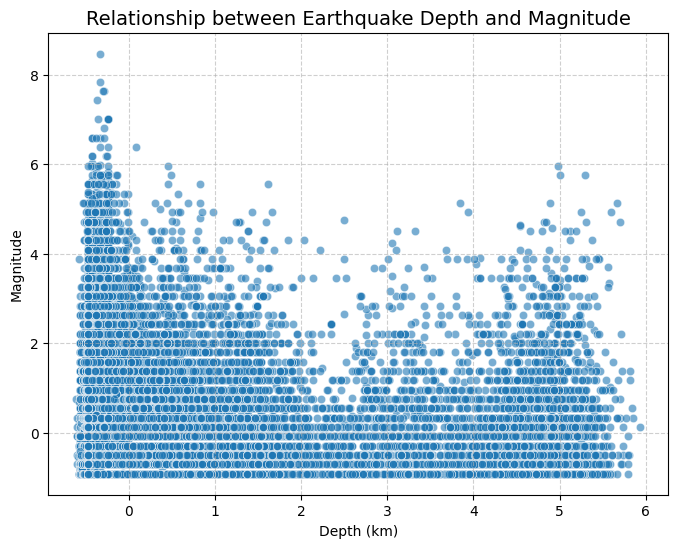

Correlation between Depth and Magnitude: -0.010
Negative correlation: deeper earthquakes tend to have lower magnitudes.


In [8]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='depth', y='mag', data=df, alpha=0.6)
plt.title('Relationship between Earthquake Depth and Magnitude', fontsize=14)
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation
correlation = df['depth'].corr(df['mag'])
print(f"Correlation between Depth and Magnitude: {correlation:.3f}")

# Interpretation:
if correlation > 0:
    print("Positive correlation: deeper earthquakes tend to have higher magnitudes (slightly).")
elif correlation < 0:
    print("Negative correlation: deeper earthquakes tend to have lower magnitudes.")
else:
    print("No significant correlation between depth and magnitude.")

Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

In [12]:
df.columns


Index(['latitude', 'longitude', 'depth', 'mag', 'magType', 'rms', 'type',
       'status', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek'],
      dtype='object')

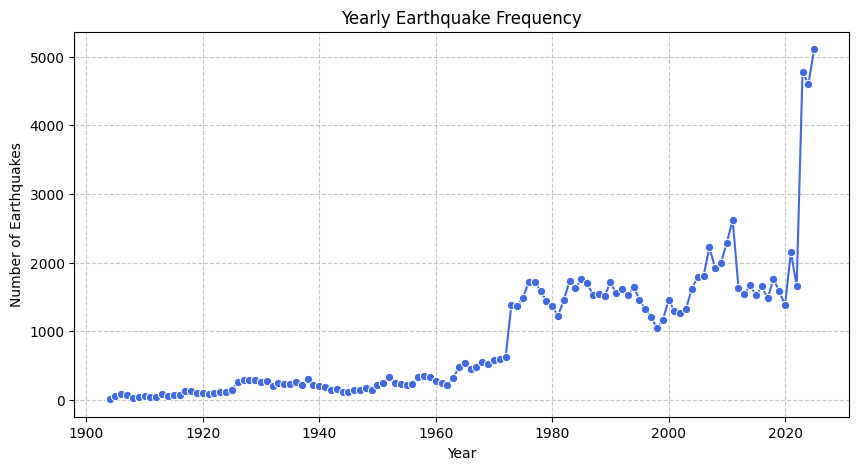

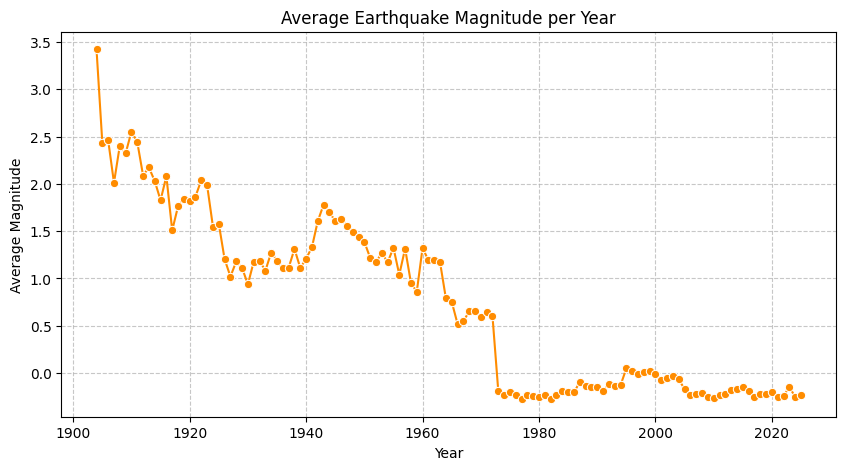

/tmp/ipython-input-1595934576.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_counts, x='Month', y='Count', palette='coolwarm')


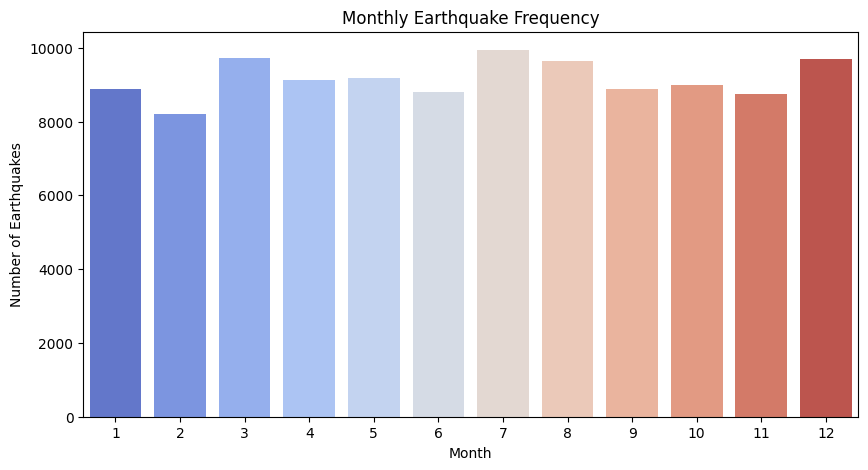

/tmp/ipython-input-1595934576.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_mag, x='Month', y='mag', palette='viridis')


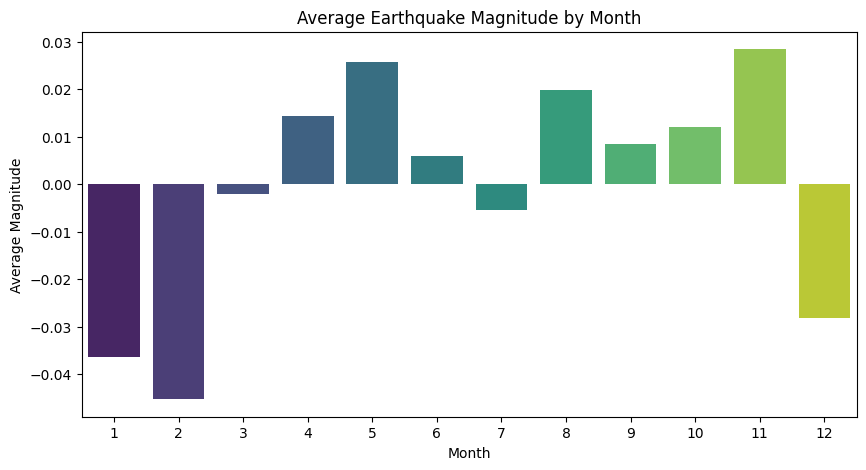

In [14]:
# Yearly Earthquake Frequency
yearly_counts = df.groupby('Year').size().reset_index(name='Count')
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_counts, x='Year', y='Count', marker='o', color='royalblue')
plt.title('Yearly Earthquake Frequency')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Yearly Average Magnitude
yearly_mag = df.groupby('Year')['mag'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_mag, x='Year', y='mag', marker='o', color='darkorange')
plt.title('Average Earthquake Magnitude per Year')
plt.xlabel('Year')
plt.ylabel('Average Magnitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Monthly Earthquake Frequency
monthly_counts = df.groupby('Month').size().reset_index(name='Count')
plt.figure(figsize=(10,5))
sns.barplot(data=monthly_counts, x='Month', y='Count', palette='coolwarm')
plt.title('Monthly Earthquake Frequency')
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.show()

# Monthly Average Magnitude
monthly_mag = df.groupby('Month')['mag'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=monthly_mag, x='Month', y='mag', palette='viridis')
plt.title('Average Earthquake Magnitude by Month')
plt.xlabel('Month')
plt.ylabel('Average Magnitude')
plt.show()

Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

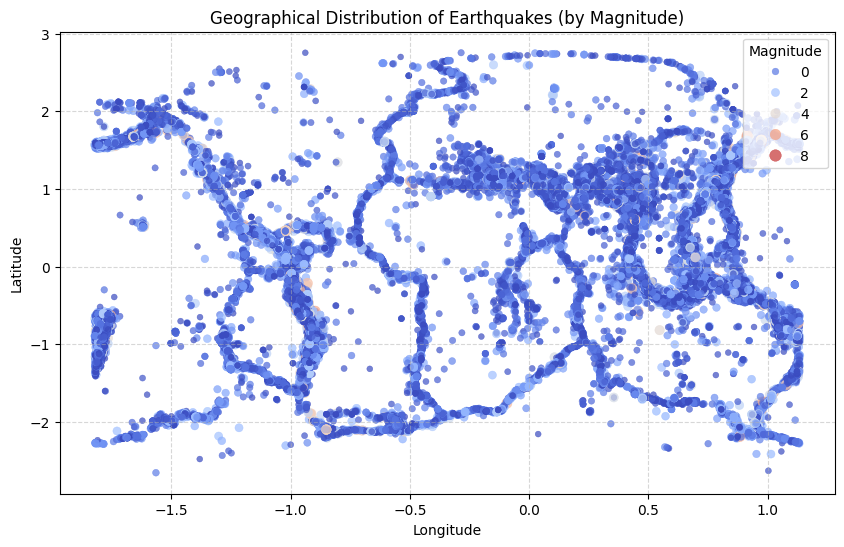

In [15]:
# Scatter plot of Earthquake locations
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='mag',           # color shows magnitude
    size='mag',          # size shows magnitude
    palette='coolwarm',
    alpha=0.7,
    edgecolor=None,
    legend='brief'
)

plt.title('Geographical Distribution of Earthquakes (by Magnitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Magnitude', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()